In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import ipywidgets

import project_utils
#OR
#from project_utils import kernel_function

In [ ]:
kernel_function?

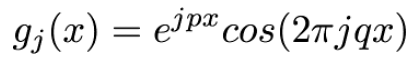

In [557]:
def kernel_function(x, j, p, q): 
    return (
        np.exp(j*p*x) * 
        np.cos(2*np.pi*j*q*x)
    )

In [558]:
n_cells = 100
x_nodes = np.linspace(0, 1, n_cells+1) 

In [559]:
# fig, ax = plt.subplots (1,1, constrained_layout=True)

# kernel =kernel_function(x_nodes, 1, 1, 1)
# kernelj =kernel_function(x_nodes, 2, 1, 1)
# kernelp =kernel_function(x_nodes, 1, 2, 1)
# kernelq =kernel_function(x_nodes, 1, 1, 2)
# ax.plot(x_nodes, kernel,label='Base')
# ax.plot(x_nodes, kernelj,label='j=2')
# ax.plot(x_nodes, kernelp,label='p=2')
# ax.plot(x_nodes, kernelq,label='q=2')
# ax.set_xlabel("x")
# ax.set_ylabel("Kernel Function, g(x)")
# ax.legend()

# plt.show()
# fig.savefig("Q1a.png")]

In [560]:
n_kernels = 20
p = -0.05
q = 0.1
j0=0
jN=30
j_values = np.linspace(j0, jN, n_kernels)

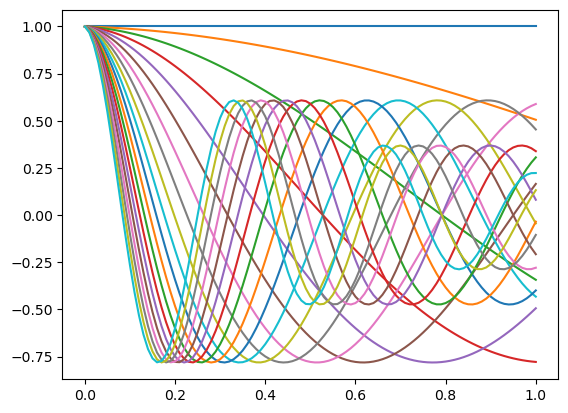

In [561]:
fig, ax = plt.subplots(1, 1) 

for jk in j_values: 
    kernel = kernel_function(x_nodes, jk, p, q)
    ax.plot(x_nodes, kernel)

## define our model 

In [562]:
#ALT: x_cells = 0.5*(x_nodes[1:] + x_nodes[:-1])
dx = np.diff(x_nodes)
#not last node + half node width# x_cells = 0.5*(x_nodes[1:] + x_nodes[:-1])
x_cells = x_nodes[:-1] + dx/2

(0.0, 0.2)

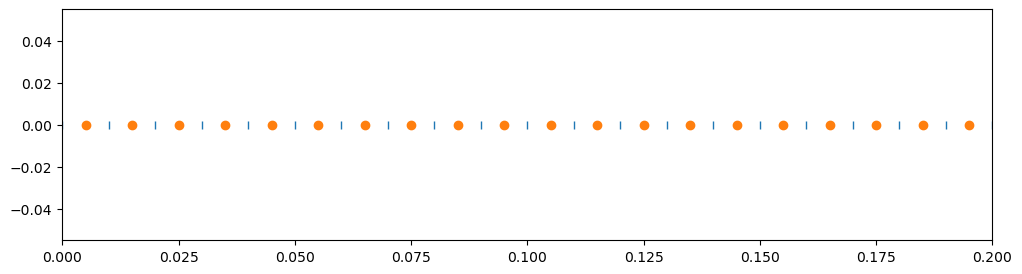

In [563]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3))

ax.plot(x_nodes, np.zeros_like(x_nodes), "|")
ax.plot(x_cells, np.zeros_like(x_cells), "o")
ax.set_xlim([0, 0.2])

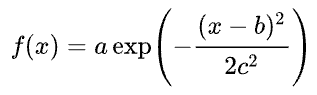

In [564]:
def build_model(
    x_cells, 
    x_boxcar_min=0.7, x_boxcar_max=0.9, amplitude_boxcar=-0.4,
    gaussian_mean=0.3, gaussian_std=0.08, amplitude_gaussian=0.9
):

    model = np.zeros_like(x_cells)  # np.zeros(len(x_cells)) 
    
    # define a boxcar 
    inds_boxcar = (
        (x_cells < x_boxcar_max) & 
        (x_cells > x_boxcar_min)
    )
    model[inds_boxcar] = amplitude_boxcar 
    
    # add a gaussian 
    gaussian = amplitude_gaussian * np.exp(
        - (x_cells-gaussian_mean)**2 / (2*gaussian_std**2) 
    )
    
    model = model + gaussian
    return model

In [565]:
model = build_model(x_cells)

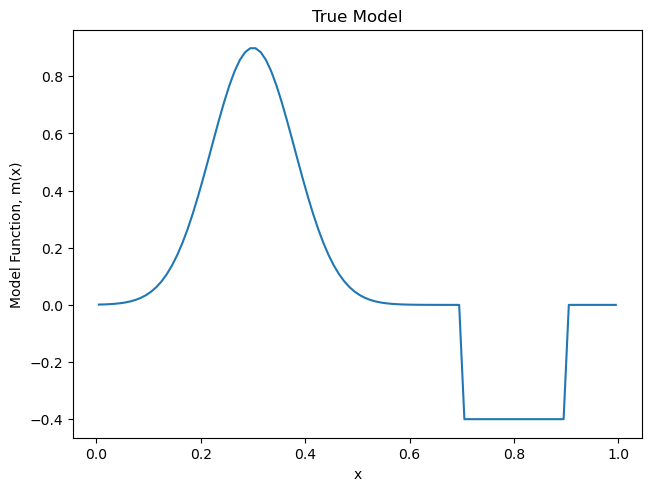

In [566]:
fig, ax = plt.subplots(1, 1, constrained_layout=True) 

ax.plot(x_cells, model) 
ax.set_xlabel("x")
ax.set_ylabel("Model Function, m(x)")
ax.set_title("True Model")
plt.show()
fig.savefig("Q1b.png")

In [567]:
def get_G(x_nodes, n_kernels, p=-0.05, q=0.1, j0=1, jN=30): 
    
    j_values = np.linspace(j0, jN, n_kernels)

    n_nodes = len(x_nodes) 
    n_cells = n_nodes - 1

    # fill an empty matrix with kernels on nodes 
    Gnodes = np.zeros((n_cells+1, n_kernels))
    for k, jk in enumerate(j_values):
        Gnodes[:, k] = kernel_function(x_nodes, jk, p, q)

    # averaging matrix from nodes to cells
    Ave = sp.spdiags([0.5*np.ones(n_nodes), 0.5*np.ones(n_nodes)], [0, 1], n_cells, n_nodes)

    # average Gnodes to cells
    Gcells = Ave @ Gnodes

    # integrate with delta x
    dx = np.diff(x_nodes)
    Deltax = sp.spdiags([dx], [0], n_cells, n_cells)

    # construct the full G matrix (N Data x N Cells) 
    G = (Ave @ Gnodes).T @ Deltax

    return G

In [654]:
G = get_G(x_nodes, n_kernels=20, p=-0.05, q=0.1, j0=0, jN=30)

In [569]:
G.shape

(20, 100)

In [570]:
data = G @ model

/var/folders/96/n3fnnlss5jdd09lc7f47c8tc0000gn/T/ipykernel_55149/3467207792.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


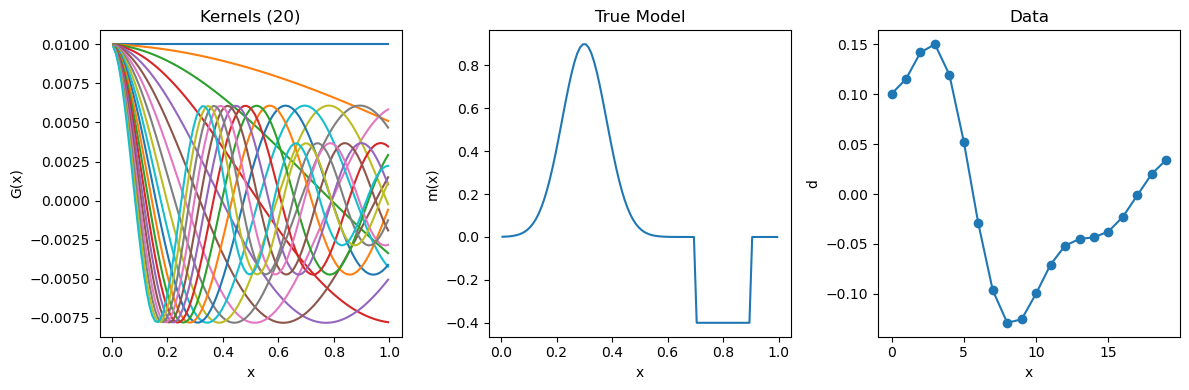

In [571]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True) 

ax[0].plot(x_cells, G.T)
ax[1].plot(x_cells, model)
ax[2].plot(data, "-o")

ax[0].set_xlabel("x")
ax[0].set_ylabel("G(x)")
ax[0].set_title("Kernels (20)")
ax[1].set_xlabel("x")
ax[1].set_ylabel("m(x)")
ax[1].set_title("True Model")
ax[2].set_xlabel("x")
ax[2].set_ylabel("d")
ax[2].set_title("Data")

plt.tight_layout()
plt.show()
fig.savefig("Q1c.png")

## Model Sensitivity (1d/1e/1f)

In [572]:
#1d
m1 = model #x_boxcar_min=0.7, x_boxcar_max=0.9, amplitude_boxcar=-0.4, gaussian_mean=0.3, gaussian_std=0.08, amplitude_gaussian=0.9
ma_up = build_model(x_cells, amplitude_boxcar= -0.2)
ma_down = build_model(x_cells, amplitude_boxcar= -0.6)
mb_up = build_model(x_cells, amplitude_gaussian = 1.1)
mb_down = build_model(x_cells, amplitude_gaussian = 0.7)

d1 = G @ m1
da_up = G @ ma_up
da_down = G @ ma_down
db_up = G @ mb_up
db_down = G @ mb_down

In [573]:
sens_daup = np.linalg.norm(d1-da_up)/np.linalg.norm(m1-ma_up)
sens_dadown = np.linalg.norm(d1-da_down)/np.linalg.norm(m1-ma_down)
sens_dbup = np.linalg.norm(d1-db_up)/np.linalg.norm(m1-mb_up)
sens_dbdown = np.linalg.norm(d1-db_down)/np.linalg.norm(m1-mb_down)

print("sens (da_up) = ", sens_daup)
print("sens (da_down) = ", sens_dadown)
print("sens (db_up) = ", sens_dbup)
print("sens (db_down) = ", sens_dbdown)

sens (da_up) =  0.08448240155390559
sens (da_down) =  0.08448240155390555
sens (db_up) =  0.1142155625627557
sens (db_down) =  0.11421556256275547


In [574]:
#1e
Gq_up = get_G(x_nodes, n_kernels=20, p=-0.05, q=0.2, j0=0, jN=30)
Gq_down = get_G(x_nodes, n_kernels=20, p=-0.05, q=0.05, j0=0, jN=30)

dq1_up = Gq_up @ m1
dq1_down = Gq_down @ m1

dqup_aup = Gq_up @ ma_up
dqdown_aup = Gq_down @ ma_up

dqup_bup = Gq_up @ mb_up
dqdown_bup = Gq_down @ mb_up

sens_qupaup = np.linalg.norm(dq1_up-dqup_aup)/np.linalg.norm(m1-ma_up)
sens_qdownaup = np.linalg.norm(dq1_down-dqdown_aup)/np.linalg.norm(m1-ma_up)

sens_qupbup = np.linalg.norm(dq1_up-dqup_bup)/np.linalg.norm(m1-mb_up)
sens_qdownbup = np.linalg.norm(dq1_down-dqdown_bup)/np.linalg.norm(m1-mb_up)

print("sens (q_up_boxamp) = ", sens_qupaup)
print("sens (q_up_gausamp) = ", sens_qdownaup)
print("sens (q_down_boxamp) = ", sens_qupbup)
print("sens (q_down_gausamp) = ", sens_qdownbup)

sens (q_up_boxamp) =  0.07397144301484276
sens (q_up_gausamp) =  0.09035689462852664
sens (q_down_boxamp) =  0.0906311698517023
sens (q_down_gausamp) =  0.1301534208092944


In [575]:
# 1f
Gp_down = get_G(x_nodes, n_kernels=20, p=-0.1, q=0.1, j0=0, jN=30)
Gp_up = get_G(x_nodes, n_kernels=20, p=-0.025, q=0.1, j0=0, jN=30)

dp1_up = Gp_up @ m1
dp1_down = Gp_down @ m1

dpup_aup = Gp_up @ ma_up
dpdown_aup = Gp_down @ ma_up

dpup_bup = Gp_up @ mb_up
dpdown_bup = Gp_down @ mb_up

sens_pupaup = np.linalg.norm(dp1_up-dpup_aup)/np.linalg.norm(m1-ma_up)
sens_pdownaup = np.linalg.norm(dp1_down-dpdown_aup)/np.linalg.norm(m1-ma_up)

sens_pupbup = np.linalg.norm(dp1_up-dpup_bup)/np.linalg.norm(m1-mb_up)
sens_pdownbup = np.linalg.norm(dp1_down-dpdown_bup)/np.linalg.norm(m1-mb_up)

print("sens (p_up_boxamp) = ", sens_pupaup)
print("sens (p_up_gausamp) = ", sens_pdownaup)
print("sens (p_down_boxamp) = ", sens_pupbup)
print("sens (p_down_gausamp) = ", sens_pdownbup)

sens (p_up_boxamp) =  0.09817136414196449
sens (p_up_gausamp) =  0.06908340960253607
sens (p_down_boxamp) =  0.12082539025531053
sens (p_down_gausamp) =  0.10394673709881051


# inversion with regularization 

In [576]:
noise_level = 0.01
dobs = data + noise_level * np.random.randn(n_kernels)

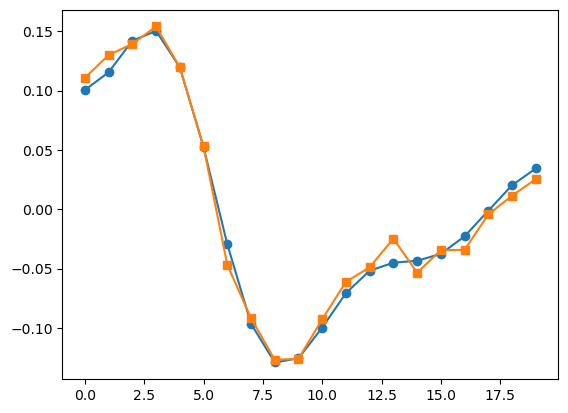

In [577]:
plt.plot(data, "-o", label="clean")
plt.plot(dobs, "-s", label="noisy")

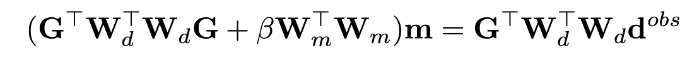

In [578]:
#2a
# x_nodes = np.linspace(0, 1, 5)   
# n_cells = len(x_nodes)-1 #4 cells
# delta_x = np.diff(x_nodes)

# dobs = np.array([1.0, 2.0])      #2 data
# n_kernels = len(dobs)

# std = 0.01
# Wd = sp.spdiags([1/std*np.ones(n_kernels)], [0], n_kernels, n_kernels) #diagonal with 1/standard dev

# dx = np.diff(x_nodes)
# Ws = sp.spdiags([np.sqrt(delta_x)], [0], n_cells, n_cells) # diagonal matrix with delta_x)

# e = np.ones(n_cells - 1)
# Wx = sp.diags([-e, e], [0, 1], shape=(n_cells-1, n_cells))

# print("Wd:\n", Wd.toarray())
# print("Ws:\n", Ws.toarray())
# print("Wx:\n", Wx.toarray())

In [579]:
def estimate_m(x_nodes, dobs, G, alphas, alphax, beta, std): 
    
    n_kernels = len(dobs)
    Wd = sp.spdiags([1/std*np.ones(n_kernels)], [0], n_kernels, n_kernels) #diagonal with 1/standard dev

    delta_x = np.diff(x_nodes) 
    n_cells = len(x_nodes) - 1
    Ws = sp.spdiags([np.sqrt(delta_x)], [0], n_cells, n_cells) # diagonal matrix with delta_x
    ones = np.ones(n_cells - 1)
    Wx = sp.diags([-ones, ones], [0, 1], shape=(n_cells - 1, n_cells)) 
    
    H = (G.T @ Wd.T @ Wd @ G + beta * alphas * Ws.T @ Ws + beta * alphax * Wx.T @ Wx)  # class - H = (G.T @ Wd.T @ Wd @ G + beta * (alpha_s * Ws.T @ Ws + alpha_x * Wx.T @ Wx))
    rhs = G.T @ Wd.T @ Wd @ dobs #+ beta @ alphas @ Ws.T @ Ws @ mref -> mref = 0
    mrec = np.linalg.solve(H, rhs)

    dpred = G @ mrec

    residual = (dpred - dobs)
    phid = (Wd @ residual).T @ Wd @ residual 
    phim = (Wm @ mrec).T @ (Wm @ mrec)

    return mrec, dpred, phid, phim

In [580]:
def plot_tikhonov_curves(beta_values, phid, phim, n_kernels=n_kernels, beta_index=0, ax=None): 
    if ax is None: 
        fig, ax = plt.subplots(1, 3, figsize=(12, 4)) 
    
    ax[0].semilogx(beta_values, phid)
    ax[1].semilogx(beta_values, phim)
    ax[2].loglog(phim, phid) 

    # plot beta at the beta index
    ax[0].semilogx(beta_values[beta_index], phid[beta_index], "ro")
    ax[1].semilogx(beta_values[beta_index], phim[beta_index], "ro")
    ax[2].loglog(phim[beta_index], phid[beta_index], "ro")
    
    ax[0].set_ylabel("$\\phi_d$")
    ax[1].set_ylabel("$\\phi_m$")
    
    ax[2].set_xlabel("$\\phi_m$")
    ax[2].set_ylabel("$\\phi_d$")
    
    # add our target misfit 
    ax[0].semilogx(beta_values, np.ones(len(beta_values))*n_kernels, "--k")
    ax[2].loglog(phim, np.ones(len(phim))*n_kernels, "--k")
    
    for a in ax[:2]:
        a.invert_xaxis()
        a.set_xlabel("$\\beta$")
    plt.tight_layout()
    fig.savefig("image3.png")

In [581]:
def plot_inversion_results(x_cells, G, model, mrecs, dobs, dpred, beta_index=0, ax=None):
    if ax is None: 
        fig, ax = plt.subplots(1, 3, figsize=(12, 3)) 
    
    ax[0].plot(x_cells, G.T)
    
    # plot our observed data 
    ax[1].plot(dobs, "o", label="observed data")
    ax[1].plot(dpreds[:, beta_index], "-s", label="predicted data")
    
    ax[2].plot(x_cells, model, label="true model")
    ax[2].plot(x_cells, mrecs[:, beta_index], label="recovered model")
    
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("kernel value")
    
    ax[1].set_xlabel("data index")
    ax[1].set_ylabel("data value")
    
    ax[2].set_xlabel("x")
    ax[2].set_ylabel("model value")
    
    ax[1].legend()
    ax[2].legend()
    
    plt.tight_layout()
    fig.savefig("image4.png")

In [582]:
def plot_all_results(beta_index=0): 
    fig, ax = plt.subplots(2, 3, figsize=(12, 6))
    
    plot_tikhonov_curves(beta_values, phid, phim, n_kernels, beta_index=beta_index, ax=ax[0, :])
    plot_inversion_results(x_cells, G, model, mrecs, dobs, dpreds, beta_index=beta_index, ax=ax[1, :])

655.1285568595509
14.858153384057864
0.11873838070787184


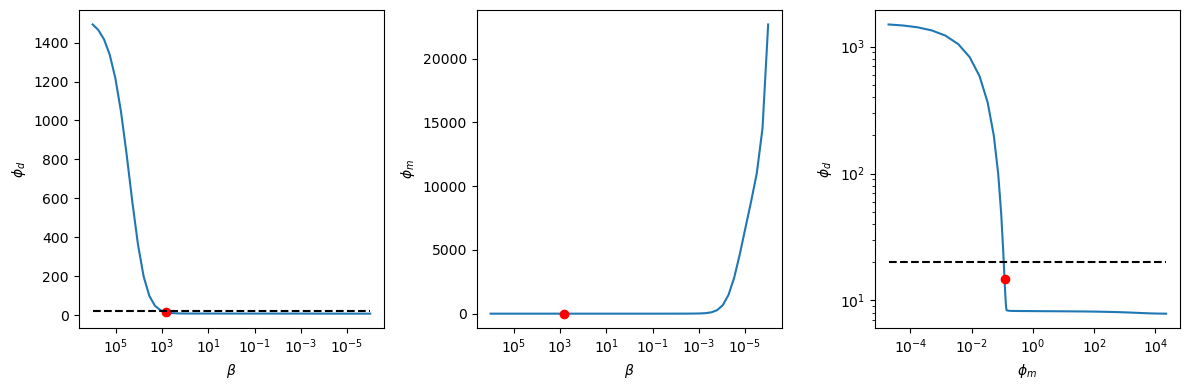

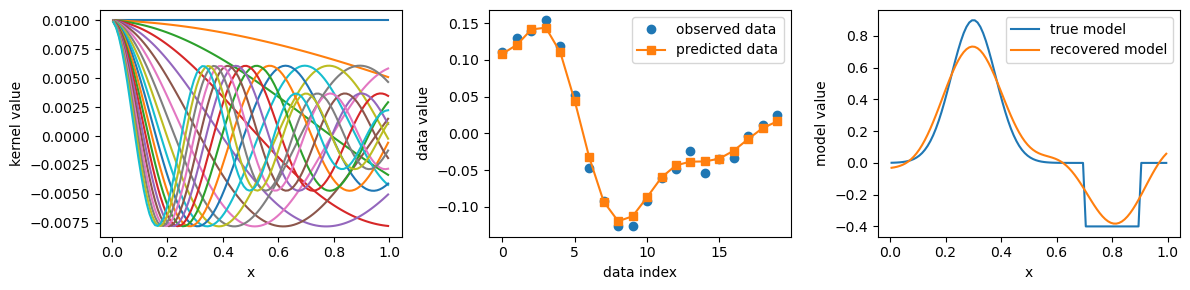

In [583]:
# do a for loop over a range of beta values 

n_betas = 50
beta_values = np.logspace(6, -6, n_betas)
phid = np.zeros(n_betas)
phim = np.zeros(n_betas)

mrecs = np.zeros((n_cells, n_betas))
dpreds = np.zeros((n_kernels, n_betas))

std = 0.01
alphas = 1
alphax = 0
for i, beta in enumerate(beta_values): 
    mrecs[:, i], dpreds[:, i], phid[i], phim[i] = estimate_m(x_nodes, dobs, G, alphas, alphax, beta, std)

z=13

plot_tikhonov_curves(beta_values, phid, phim, n_kernels, beta_index=z, ax=None)
plot_inversion_results(x_cells, G, model, mrecs, dobs, dpreds, beta_index=z, ax=None)
print(beta_values[z])
print(phid[z])
print(phim[z])

1072.2672220103232
23.064588117134335
0.11744453857695128


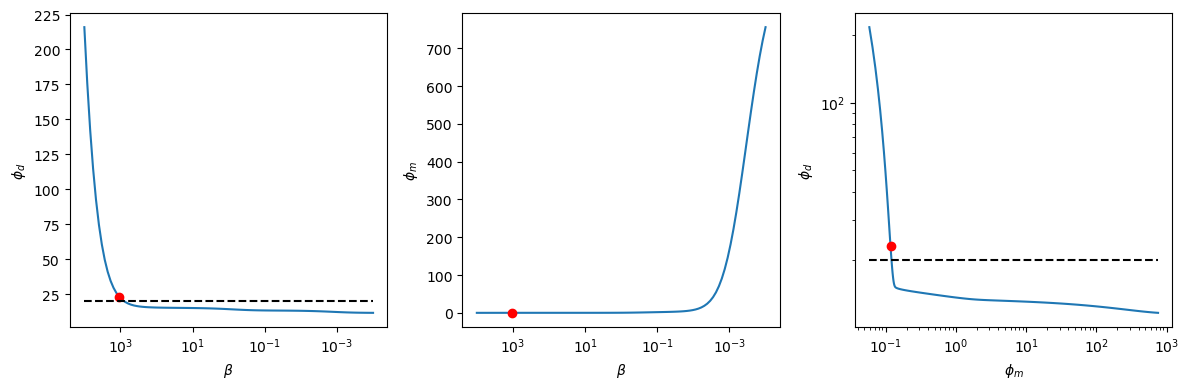

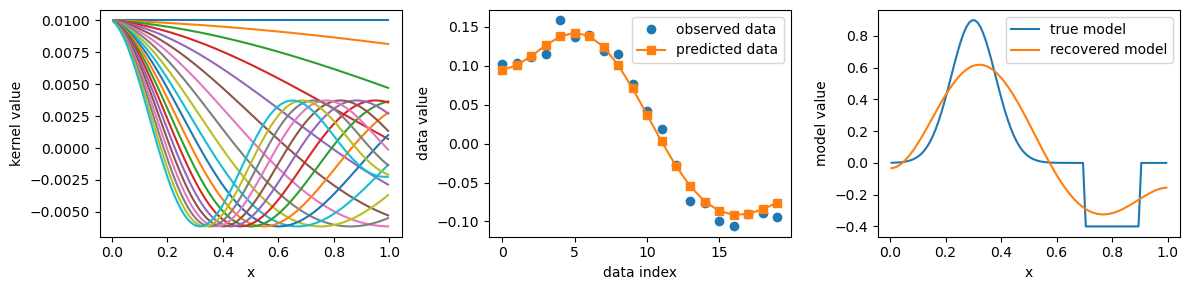

In [457]:
#3c - effect of kernel oscillations

Gq_up = get_G(x_nodes, n_kernels=20, p=-0.05, q=0.5, j0=0, jN=30)
Gq_down = get_G(x_nodes, n_kernels=20, p=-0.05, q=0.05, j0=0, jN=30)
dq1_up = Gq_up @ m1
dq1_down = Gq_down @ m1

noise_level = 0.01
dobs_q1up = dq1_up + noise_level * np.random.randn(n_kernels)
dobs_q1down = dq1_down + noise_level * np.random.randn(n_kernels)

n_betas = 100
beta_values = np.logspace(4, -4, n_betas)
phid = np.zeros(n_betas)
phim = np.zeros(n_betas)

mrecs = np.zeros((n_cells, n_betas))
dpreds = np.zeros((n_kernels, n_betas))

std = 0.01
alphas = 0.5
alphax = 0.5
for i, beta in enumerate(beta_values): 
    mrecs[:, i], dpreds[:, i], phid[i], phim[i] = estimate_m(x_nodes, dobs_q1down, Gq_down, alphas, alphax, beta, std)

z=12#index

plot_tikhonov_curves(beta_values, phid, phim, n_kernels, beta_index=z, ax=None)

plot_inversion_results(x_cells, Gq_down, model, mrecs, dobs_q1down, dpreds, beta_index=z, ax=None)


print(beta_values[z])
print(phid[z])
print(phim[z])

95.45484566618337
11.777731101246715
0.150222221513859


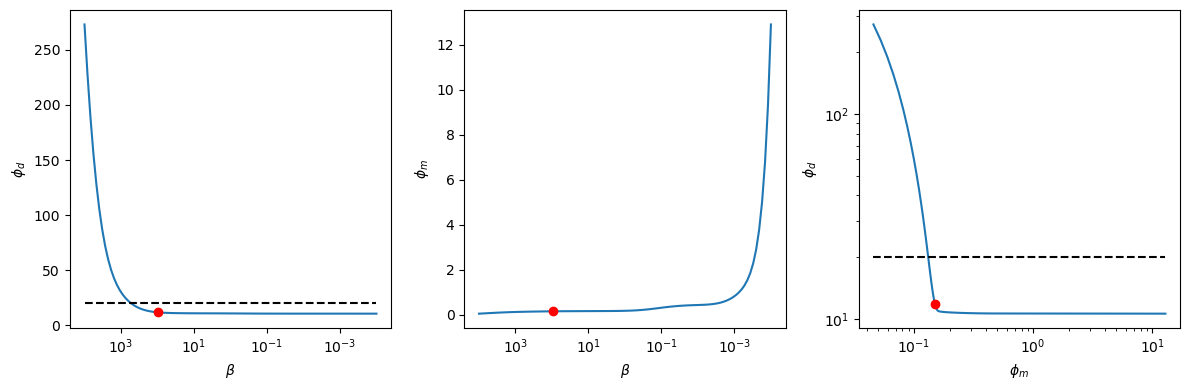

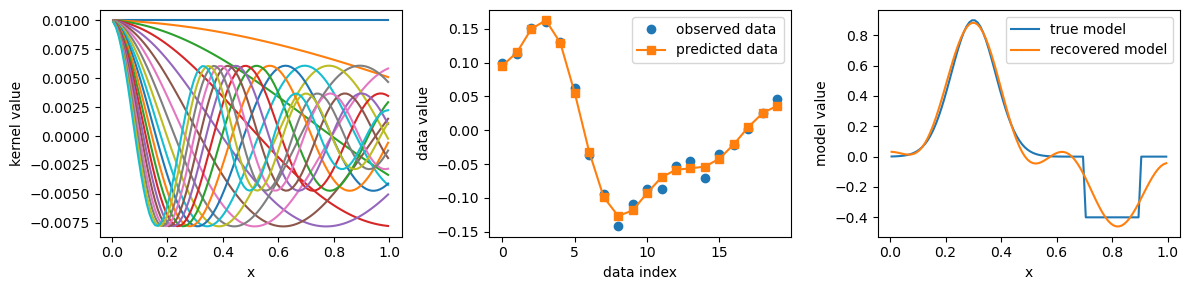

In [697]:
#3c - effect of noise

noise_level = 0.01
dobs_noise = data + noise_level * np.random.randn(n_kernels)

n_betas = 100
beta_values = np.logspace(4, -4, n_betas)
phid = np.zeros(n_betas)
phim = np.zeros(n_betas)

mrecs = np.zeros((n_cells, n_betas))
dpreds = np.zeros((n_kernels, n_betas))

std = 0.011
alphas = 0.5
alphax = 0.5
for i, beta in enumerate(beta_values): 
    mrecs[:, i], dpreds[:, i], phid[i], phim[i] = estimate_m(x_nodes, dobs_noise, G, alphas, alphax, beta, std)

z=25   #index

plot_tikhonov_curves(beta_values, phid, phim, n_kernels, beta_index=z, ax=None)

plot_inversion_results(x_cells, G, model, mrecs, dobs_noise, dpreds, beta_index=z, ax=None)

print(beta_values[z])
print(phid[z])
print(phim[z])

# solving with SVD

In [921]:
n_cells = 100
x_nodes = np.linspace(0, 1, n_cells+1) 
dx = np.diff(x_nodes)
x_cells = x_nodes[:-1] + dx/2

In [922]:
G_svd = get_G(x_nodes, n_kernels=20, p=-0.05, q=0.1, j0=0, jN=30) 

In [923]:
U, singular_vals, VT = np.linalg.svd(G_svd, full_matrices=False)
V = VT.T 

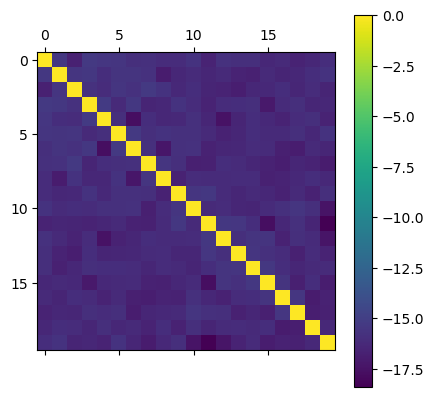

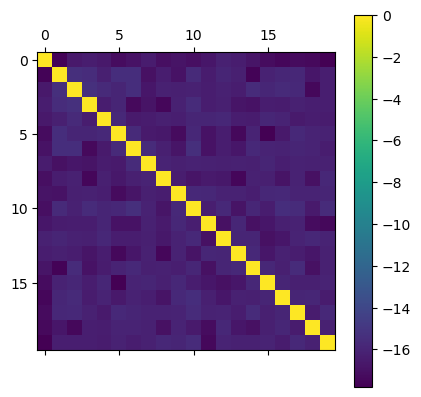

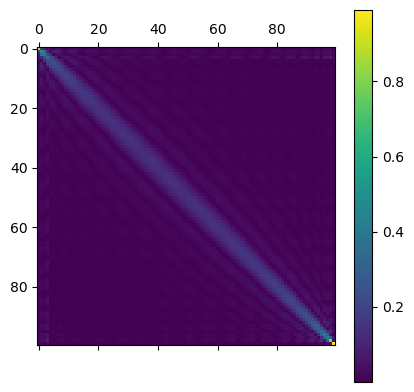

In [924]:
plt.colorbar(plt.matshow(np.log10(np.abs(V.T @ V))))
plt.colorbar(plt.matshow(np.log10(np.abs(U.T @ U))))
plt.colorbar(plt.matshow((np.abs(V @ V.T))))

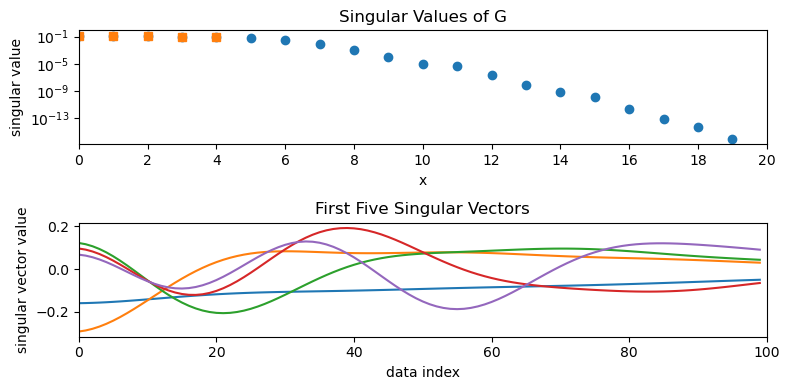

In [925]:
fig, ax = plt.subplots(2, 1, figsize=(8, 4)) 

n_vectors = 5

ax[0].semilogy(singular_vals, "o")
ax[0].semilogy(singular_vals[:n_vectors], "s")
ax[0].set_xlabel("x")
ax[0].set_ylabel("singular value")
ax[0].set_title("Singular Values of G")
ax[0].set_xlim(0,20)
ax[0].set_xticks(np.arange(0, 21, 2))

ax[1].plot(V[:, :n_vectors]);
ax[1].set_xlabel("data index")
ax[1].set_ylabel("singular vector value")
ax[1].set_title("First Five Singular Vectors")
ax[1].set_xlim(0,100)

plt.tight_layout()
fig.savefig("image.png")

In [926]:
def get_m_at_index(data, index=0):  
    uiTd = U[:, index].T @ data
    return uiTd / singular_vals[index] * V[:, index]

In [927]:
mtrue = build_model(x_cells)
dobs_svd = G_svd @ mtrue

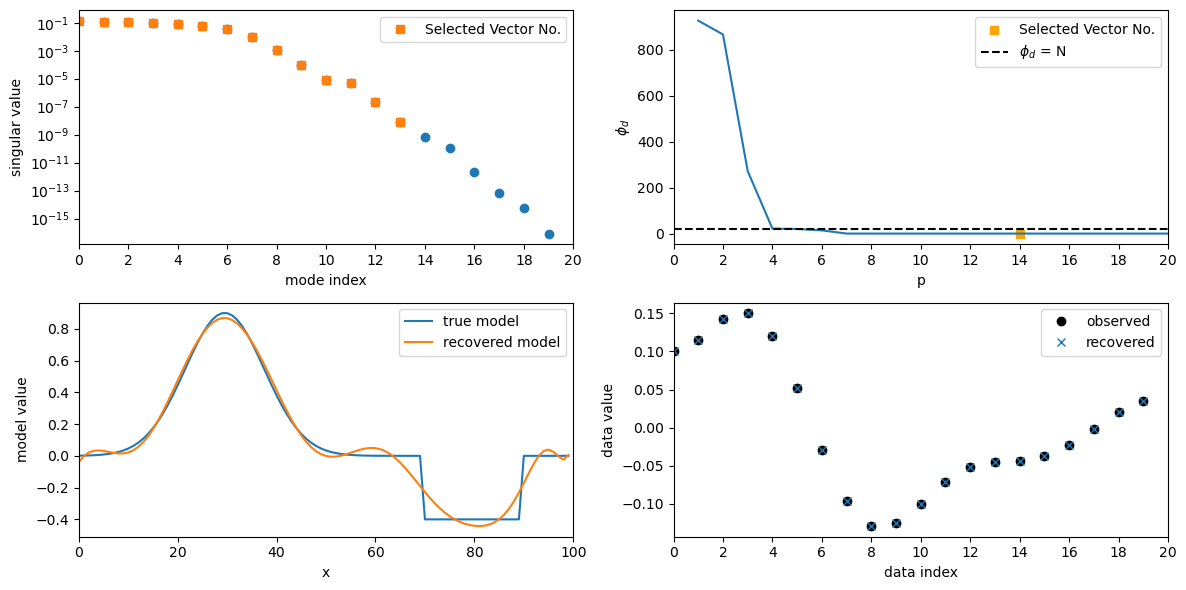

In [928]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6)) 

n_vectors = 14
mrec = np.zeros(len(x_cells))

ax[0,0].semilogy(singular_vals, "o")
ax[0,0].semilogy(singular_vals[:n_vectors], "s", label="Selected Vector No.")
ax[0,0].set_xlabel("mode index")
ax[0,0].set_ylabel("singular value")
ax[0,0].legend()
ax[0,0].set_xlim(0,20)
ax[0,0].set_xticks(np.arange(0, 21, 2))

p_values = np.arange(1, n_kernels+1)
phid = np.zeros_like(p_values, dtype=float)
residual = np.zeros_like(p_values, dtype=float)
        
# for i in range(n_vectors): #this plots the FULL phid for fig 2
#     mi = get_m_at_index(dobs_svd, i)
#     mrec += mi 
#     residual[i] = np.linalg.norm(G_svd @ mrec - dobs_svd)/std #divide by std and square to get to same scale as phi_d~N
#     phid[i] += residual[i]**2

for p in p_values:
    mrec_temp = np.zeros(len(x_cells))
    
    for i in range(p):
        mi = get_m_at_index(dobs_svd, i)
        mrec_temp += mi
    residual = G_svd @ mrec_temp - dobs_svd
    phid[p-1] = np.linalg.norm(residual / std)**2

ax[0,1].plot(p_values, phid)
ax[0,1].scatter(p_values[n_vectors-1], phid[n_vectors-1], c="orange", marker="s", label="Selected Vector No.")
ax[0,1].set_xlabel("p")
ax[0,1].set_ylabel("$\phi_d$")
ax[0,1].axhline(n_kernels, linestyle="--", c="k", label="$\phi_d$ = N")
ax[0,1].legend(loc="upper right")
ax[0,1].set_xlim(0,20)
ax[0,1].set_xticks(np.arange(0, 21, 2))

for i in range(n_vectors): #RESETS mrec to only n_vectors for fig 3+4
    mi = get_m_at_index(dobs_svd, i)

    mrec += mi 

ax[1,0].plot(mtrue,label="true model")
ax[1,0].plot(mrec, label="recovered model")
ax[1,0].set_xlabel("x")
ax[1,0].set_ylabel("model value")
ax[1,0].legend(loc="upper right")
ax[1,0].set_xlim(0,100)

ax[1,1].plot(dobs_svd, "ko", label="observed")
ax[1,1].plot(G_svd @ mrec, "x", label="recovered")
ax[1,1].set_xlabel("data index")
ax[1,1].set_ylabel("data value")
ax[1,1].legend(loc="upper right")
ax[1,1].set_xlim(0,20)
ax[1,1].set_xticks(np.arange(0, 21, 2))

plt.tight_layout()
fig.savefig("image2.png")

## Sensitivities (4D)

In [911]:
n_cells = 100
x_nodes = np.linspace(0, 1, n_cells+1) 
dx = np.diff(x_nodes)
x_cells = x_nodes[:-1] + dx/2

kernelsens = 20
#noise_sens = 0.01

G_svd = get_G(x_nodes, n_kernels=kernelsens, p=-0.05, q=0.1, j0=0, jN=30)

U, singular_vals, VT = np.linalg.svd(G_svd, full_matrices=False)
V = VT.T 

mtrue = build_model(x_cells)
dobs_svd = G_svd @ mtrue #+ noise_sens * np.random.randn(n_kernels)

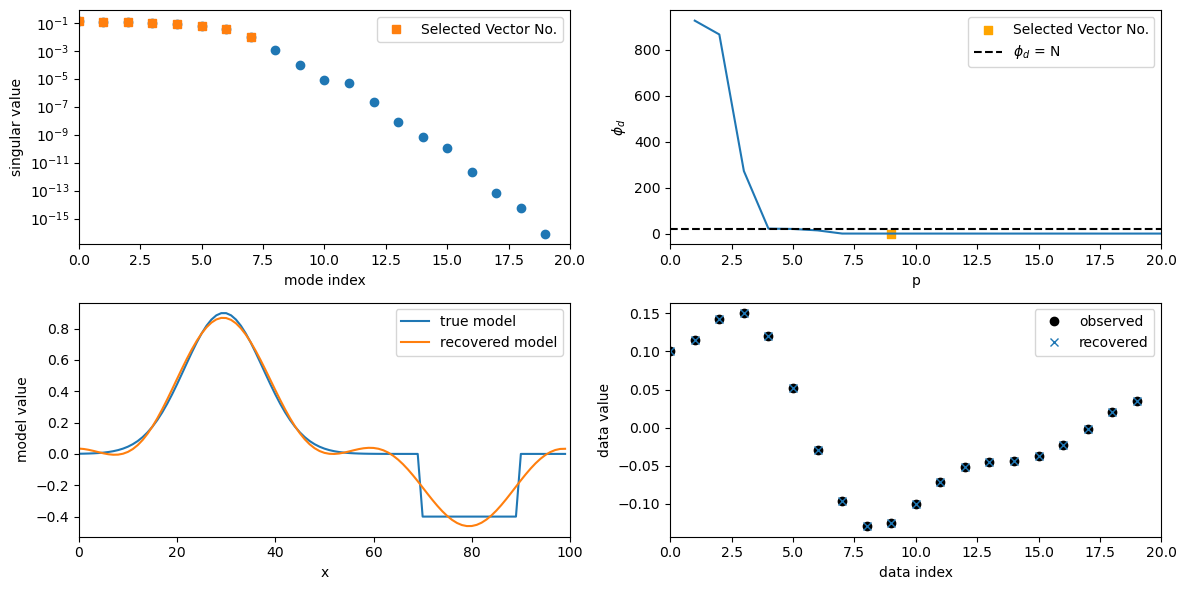

In [920]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6)) 

n_vectors = 8
mrec = np.zeros(len(x_cells))

ax[0,0].semilogy(singular_vals, "o")
ax[0,0].semilogy(singular_vals[:n_vectors], "s", label="Selected Vector No.")
ax[0,0].set_xlabel("mode index")
ax[0,0].set_ylabel("singular value")
ax[0,0].legend()
ax[0,0].set_xlim(0,kernelsens)

p_values = np.arange(1, n_kernels+1)
phid = np.zeros_like(p_values, dtype=float)
residual = np.zeros_like(p_values, dtype=float)
        
for p in p_values:
    mrec_temp = np.zeros(len(x_cells))
    
    for i in range(p):
        mi = get_m_at_index(dobs_svd, i)
        mrec_temp += mi
    residual = G_svd @ mrec_temp - dobs_svd
    phid[p-1] = np.linalg.norm(residual / std)**2

ax[0,1].plot(p_values, phid)
ax[0,1].scatter(p_values[n_vectors], phid[n_vectors], c="orange", marker="s", label="Selected Vector No.")
ax[0,1].set_xlabel("p")
ax[0,1].set_ylabel("$\phi_d$")
ax[0,1].axhline(n_kernels, linestyle="--", c="k", label="$\phi_d$ = N")
ax[0,1].legend(loc="upper right")
ax[0,1].set_xlim(0,kernelsens)

for i in range(n_vectors): #RESETS mrec to only n_vectors for fig 3+4
    mi = get_m_at_index(dobs_svd, i)

    mrec += mi 

ax[1,0].plot(mtrue,label="true model")
ax[1,0].plot(mrec, label="recovered model")
ax[1,0].set_xlabel("x")
ax[1,0].set_ylabel("model value")
ax[1,0].legend(loc="upper right")
ax[1,0].set_xlim(0,n_cells)

ax[1,1].plot(dobs_svd, "ko", label="observed")
ax[1,1].plot(G_svd @ mrec, "x", label="recovered")
ax[1,1].set_xlabel("data index")
ax[1,1].set_ylabel("data value")
ax[1,1].legend(loc="upper right")
ax[1,1].set_xlim(0,kernelsens)

plt.tight_layout()
fig.savefig("image4.png")